In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import transforms
import os, yaml, sparse, glob
plt.rcParams["figure.dpi"] = 150
plt.rcParams['axes.titlepad'] = 10

import scipy.stats as st
from sklearn.linear_model import Ridge, RidgeCV, LogisticRegression, LogisticRegressionCV, ElasticNet, ElasticNetCV
from sklearn.metrics import roc_auc_score, roc_curve, auc, accuracy_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold

from Bio import SeqIO
import subprocess
#from mic_tb_cnn_codebase import *
from sklearn.metrics import confusion_matrix

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
moxi_cnn_summaries = pd.read_csv("moxi_cnn_summaries.csv")
rif_cnn_summaries = pd.read_csv("rif_cnn_summaries.csv")
#cnn_summaries_lineage = pd.read_csv("cnn_summaries_lineage.csv")

# get colors
# sns.color_palette("Set2").as_hex()[0]
color_dict = {"CNN": '#66c2a5', "Regression": '#fc8d62'}

In [47]:
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
#who_variants_conf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_Cat1orCat2.csv")

freschi_snps = pd.read_excel("../lasso/Freschi_SNPs.xlsx")
#freschi_snps["position"] = freschi_snps["position"].astype(int)

#tb_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes.csv")
tb_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

df_moxi = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/20220904_data_clean.csv")

# Moxifloxacin, Used MAF = 0.999 for all models and increased `max_iter` to make sure models converged

## Quantitative, gyrBA Only, MAF = 0.999

In [48]:
def analyze_linReg_models(path, binary=False):
    
    if binary:
        prefix = "binary_"
    else:
        prefix = ""
    
    model_res = pd.read_csv(os.path.join(results_path, path, "ridge", f"{prefix}ridge_results.csv"))

    if binary:
        metrics = ["Sensitivity", "Specificity", "AUC", "AUC_PR"]
        model_res["Num_Loci"] = "Binary"
    else:
        metrics = ["MAE", "RMSE", "Pearson R", "Sensitivity", "Specificity", "AUC", "AUC_PR"]
        
    for metric in metrics:
        print(f"{metric}: {np.round(model_res.query('CV==0')[metric].values[0], 4)}, CI: {np.round(np.percentile(model_res.query('CV==1')[metric], q=[2.5, 97.5]), 4)}")
        
    return model_res

In [4]:
# bdq_6Loci = analyze_linReg_models("20220923_bdq_6Loci", binary=False)

In [112]:
rif_rpoBC = analyze_linReg_models("20220904_rif_rpoBC", binary=False)
rif_rpoBC["Lineage"] = 0
print("\n")
rif_rpoBC_binary = analyze_linReg_models("20220904_rif_rpoBC", binary=True)
rif_rpoBC_binary["Lineage"] = 0

MAE: 0.8275, CI: [0.8217 0.8217]
RMSE: 1.1829, CI: [1.1866 1.1866]
Pearson R: 0.9069, CI: [0.9065 0.9065]
Sensitivity: 0.952, CI: [0.952 0.952]
Specificity: 0.9878, CI: [0.9888 0.9888]
AUC: 0.9699, CI: [0.9704 0.9704]
AUC_PR: 0.9622, CI: [0.9633 0.9633]


Sensitivity: 0.9607, CI: [0.9574 0.9574]
Specificity: 0.9837, CI: [0.9878 0.9878]
AUC: 0.9722, CI: [0.9726 0.9726]
AUC_PR: 0.9625, CI: [0.9651 0.9651]


In [7]:
rif_rpoBC_lineage = analyze_linReg_models("20221006_rif_rpoBC", binary=False)
print("\n")
rif_rpoBC_binary_lineage = analyze_linReg_models("20221006_rif_rpoBC", binary=True)

MAE: 0.8427, CI: [0.8418 0.8418]
RMSE: 1.1982, CI: [1.2058 1.2058]
Pearson R: 0.9044, CI: [0.9034 0.9034]
Sensitivity: 0.9552, CI: [0.9531 0.9531]
Specificity: 0.9857, CI: [0.9878 0.9878]
AUC: 0.9705, CI: [0.9704 0.9704]
AUC_PR: 0.9618, CI: [0.9628 0.9628]


Sensitivity: 0.9607, CI: [0.9574 0.9574]
Specificity: 0.9837, CI: [0.9837 0.9837]
AUC: 0.9722, CI: [0.9706 0.9706]
AUC_PR: 0.9625, CI: [0.9608 0.9608]


In [9]:
moxi_gyrBA_lineage = analyze_linReg_models("20221006_moxi_gyrBA", binary=False)
moxi_gyrBA_lineage["CC"] = 0.5
print("\n")
moxi_gyrBA_binary_lineage = analyze_linReg_models("20221006_moxi_gyrBA", binary=True)
moxi_gyrBA_binary_lineage["CC"] = 0.5

MAE: 0.6146, CI: [0.6376 0.6376]
RMSE: 0.8449, CI: [0.8561 0.8561]
Pearson R: 0.8162, CI: [0.8107 0.8107]
Sensitivity: 0.8201, CI: [0.8452 0.8452]
Specificity: 0.9825, CI: [0.9809 0.9809]
AUC: 0.9013, CI: [0.913 0.913]
AUC_PR: 0.7705, CI: [0.7845 0.7845]


Sensitivity: 0.8912, CI: [0.8661 0.8661]
Specificity: 0.9734, CI: [0.9809 0.9809]
AUC: 0.9323, CI: [0.9235 0.9235]
AUC_PR: 0.7928, CI: [0.8017 0.8017]


In [10]:
moxi_gyrBA = analyze_linReg_models("20220902_moxi_gyrBA", binary=False)
moxi_gyrBA["CC"] = 0.5
moxi_gyrBA["Lineage"] = 0
print("\n")
moxi_gyrBA_binary = analyze_linReg_models("20220902_moxi_gyrBA", binary=True)
moxi_gyrBA_binary["CC"] = 0.5
moxi_gyrBA_binary["Lineage"] = 0

MAE: 0.6736, CI: [0.6763 0.6763]
RMSE: 0.931, CI: [0.9312 0.9312]
Pearson R: 0.7711, CI: [0.771 0.771]
Sensitivity: 0.8494, CI: [0.887 0.887]
Specificity: 0.9784, CI: [0.9767 0.9767]
AUC: 0.9139, CI: [0.9319 0.9319]
AUC_PR: 0.7779, CI: [0.8023 0.8023]


Sensitivity: 0.887, CI: [0.8787 0.8787]
Specificity: 0.9726, CI: [0.9792 0.9792]
AUC: 0.9298, CI: [0.9289 0.9289]
AUC_PR: 0.7863, CI: [0.8053 0.8053]


## Quantitative, 12 Loci

In [88]:
moxi_12Loci = analyze_linReg_models("20220907_moxi_12Loci", binary=False)
moxi_12Loci["CC"] = 0.5
moxi_12Loci["Lineage"] = 0

MAE: 0.6125, CI: [0.6249 0.6249]
RMSE: 0.8458, CI: [0.8546 0.8546]
Pearson R: 0.8157, CI: [0.8114 0.8114]
Sensitivity: 0.8201, CI: [0.8243 0.8243]
Specificity: 0.98, CI: [0.98 0.98]
AUC: 0.9001, CI: [0.9022 0.9022]
AUC_PR: 0.7604, CI: [0.7639 0.7639]


# Rifampicin

In [113]:
rif_cnn_summaries["Lineage"] = 0
rif_combined = pd.concat([rif_cnn_summaries, rif_rpoBC, rif_rpoBC_binary, rif_rpoBC_lineage, 
                          rif_rpoBC_binary_lineage, cnn_summaries_lineage.query("Drug=='RIF'")]).reset_index(drop=True)
rif_combined["Num_Loci"] = rif_combined["Num_Loci"].astype(str)

## Quantitative Model Comparison

In [124]:
def plot_quant_rif(df, x_var, quant_var, ylabel, title, save_title=None):

    rif_quant_plot = df.query("CV > 0 & Num_Loci != 'Binary'").melt(id_vars=["Model", x_var], value_vars=quant_var)
    rif_quant_plot = rif_quant_plot.replace("LinReg", "Regression")

    fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.5))
    sns.stripplot(x=x_var, y="value",
                    hue="Model",
                  dodge=True,
                    hue_order=["Regression", "CNN"],
                    data = rif_quant_plot,
                    palette=color_dict,
                  linewidth=0.5,
                  ax=ax
                     )



    #plt.ylim(0.7, 0.85)
    ax.get_legend().remove()
    
    legend = plt.legend(loc="lower left", fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.title(title)
    plt.xlabel("")
    plt.ylabel(ylabel)
    
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)

    # print(st.ttest_rel(df.query("Model == 'CNN' & Num_Loci == '1' & CV > 0").sort_values("CV")[quant_var].values,
    #              df.query("Model == 'LinReg' & CV > 0").sort_values("CV")[quant_var].values,
    #              alternative="two-sided"
    #             ))

In [139]:
st.ttest_ind(rif_combined.query("CV > 0 & Lineage == 0 & Model == 'CNN' & Num_Loci == '1'")["MAE"],
             rif_combined.query("CV > 0 & Lineage == 1 & Model == 'CNN' & Num_Loci == '1'")["MAE"],
             alternative="two-sided",
             equal_var=False
            )

Ttest_indResult(statistic=-1.316863759116786, pvalue=0.22684198126445718)

In [138]:
st.ttest_ind(rif_combined.query("CV > 0 & Lineage == 0 & Model == 'LinReg' & Num_Loci == '1'")["MAE"],
             rif_combined.query("CV > 0 & Lineage == 1 & Model == 'LinReg' & Num_Loci == '1'")["MAE"],
             alternative="two-sided",
             equal_var=False
            )

Ttest_indResult(statistic=-1.5294742112959132, pvalue=0.16740109915181636)

In [140]:
st.ttest_ind(rif_combined.query("CV > 0 & Lineage == 1 & Model == 'CNN' & Num_Loci == '1'")["MAE"],
             rif_combined.query("CV > 0 & Lineage == 1 & Model == 'LinReg' & Num_Loci == '1'")["MAE"],
             alternative="two-sided",
             equal_var=False
            )

Ttest_indResult(statistic=-25.51674725069761, pvalue=1.4239577185511336e-08)

In [141]:
st.ttest_ind(rif_combined.query("CV > 0 & Lineage == 0 & Model == 'CNN' & Num_Loci == '1'")["MAE"],
             rif_combined.query("CV > 0 & Lineage == 0 & Model == 'LinReg' & Num_Loci == '1'")["MAE"],
             alternative="two-sided",
             equal_var=False
            )

Ttest_indResult(statistic=-18.85684111244458, pvalue=1.368327474619055e-07)

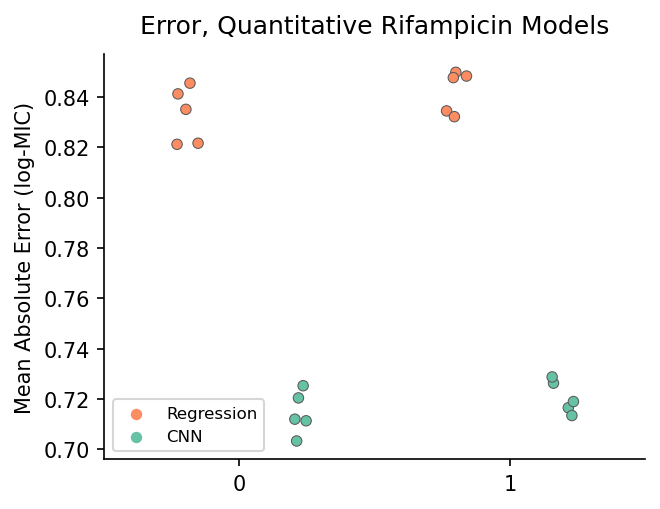

In [125]:
plot_quant_rif(rif_combined, "Lineage", "MAE", "Mean Absolute Error (log-MIC)", "Error, Quantitative Rifampicin Models", "../Figures/rif_mae.png")

## Binary Model Comparison

In [190]:
def plot_binary_rif(binary_var, ymin, legend_loc, save_title=None):
    
    rif_binary_plot = rif_combined.melt(id_vars=["Model", "Num_Loci"], value_vars=[binary_var])
    rif_binary_plot["Model"] = rif_binary_plot["Model"].replace("LinReg", "Regression")
    rif_binary_plot["Model"] = rif_binary_plot["Model"].replace("LogReg", "Regression")
    rif_binary_plot["Num_Loci"] = rif_binary_plot["Num_Loci"].replace("1", "Quantitative")

    rif_binary_plot = rif_binary_plot.sort_values("Model")

    fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))
    sns.stripplot(x="Num_Loci", y="value",
                    hue="Model", 
                    data = rif_binary_plot,
                    palette=color_dict,
                  hue_order=["Regression", "CNN"],
                  order=["Binary", "Quantitative"],
                      dodge=True,
                  #alpha=0.75,
                  linewidth=0.5,
                  ax=ax
                     )



    plt.ylim(ymin, 1)
    ax.get_legend().remove()
    plt.title(f"{binary_var}, Rifampicin Models")
    #+ " of Rifampicin prediction from $\it{rpoBC}$")
    plt.xlabel("")
    
    legend = plt.legend(loc=legend_loc, fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.ylabel(binary_var)
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)

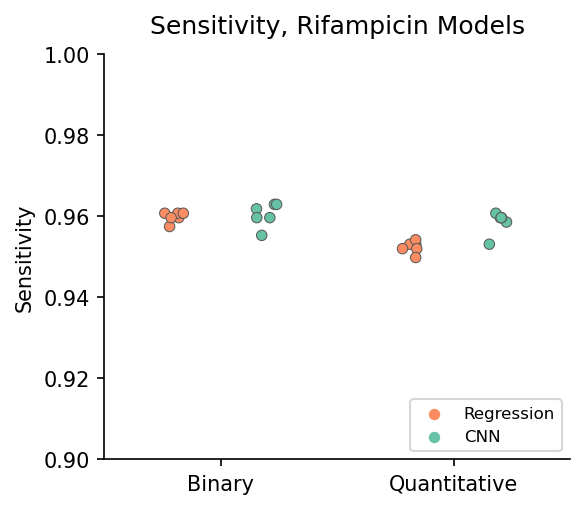

In [191]:
plot_binary_rif("Sensitivity", 0.9, "lower right", save_title="../Figures/rif_sens.png")

In [192]:
#plot_binary_rif("AUC", 0.95, "upper right", save_title=None)

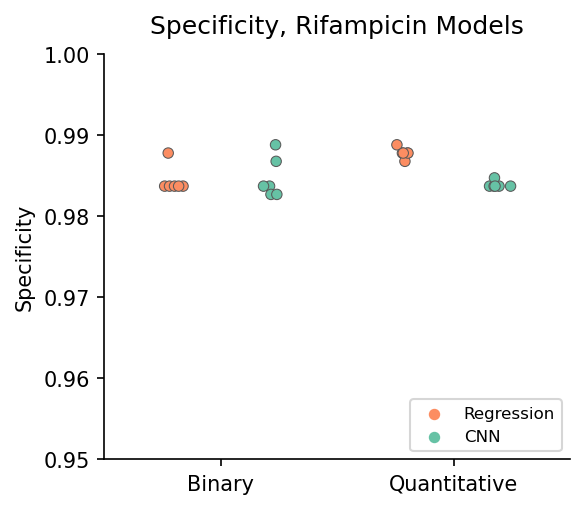

In [193]:
plot_binary_rif("Specificity", 0.95, "lower right", save_title="../Figures/rif_spec.png")

# Moxifloxacin

In [73]:
moxi_combined = pd.concat([moxi_gyrBA, moxi_gyrBA_binary, moxi_gyrBA_lineage, #moxi_gyrBA_binary_lineage, 
                           moxi_cnn_summaries# moxi_12Loci
]).reset_index(drop=True)

moxi_combined["Num_Loci"] = moxi_combined["Num_Loci"].astype(str)

In [49]:
# plot_quant_moxi(moxi_combined.query("Lineage==0 & Num_Loci != '12'"), "Model", "MAE", "Mean Absolute Error (log-MIC)", "Error, Moxifloxacin Models", "../Figures/moxi_mae_og.png")

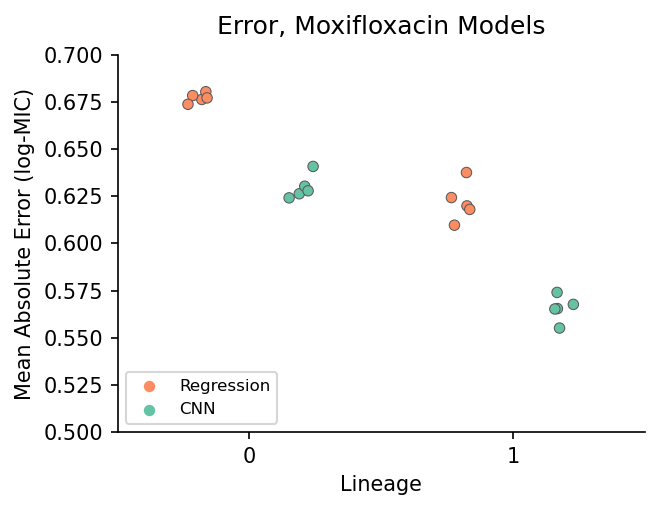

In [76]:
plot_quant_moxi(moxi_combined.query("Num_Loci != '12'"), "Lineage", "MAE", "Mean Absolute Error (log-MIC)", "Error, Moxifloxacin Models",  "../Figures/moxi_mae_lineage.png")

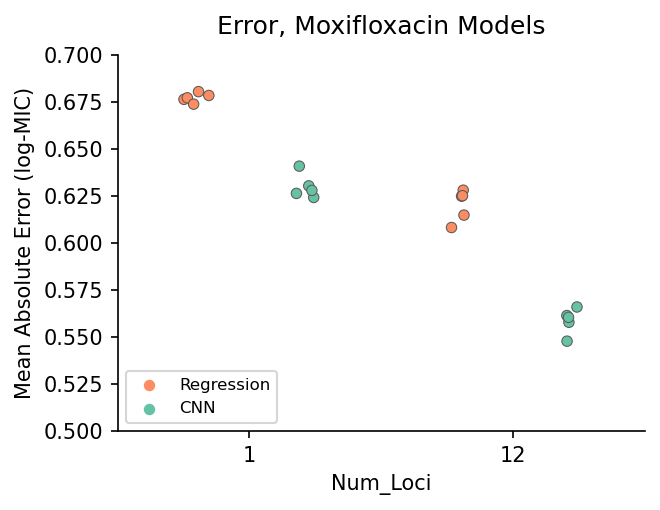

In [152]:
plot_quant_moxi(moxi_combined.query("Lineage == 0"), "Num_Loci", "MAE", "Mean Absolute Error (log-MIC)", "Error, Moxifloxacin Models", "moxi_mae_multiloci.png")

In [63]:
def plot_quant_moxi(df, x_var, quant_var, ylabel, title, save_title=None):

    if x_var == "Model":
        moxi_quant_plot = df.query("CV > 0 & Num_Loci != 'Binary'").melt(id_vars=["Model"], value_vars=quant_var)
    else:
        moxi_quant_plot = df.query("CV > 0 & Num_Loci != 'Binary'").melt(id_vars=["Model", x_var], value_vars=quant_var)
    moxi_quant_plot["Model"] = moxi_quant_plot["Model"].replace("LinReg", "Regression")

    fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.5))
    sns.stripplot(x=x_var, y="value",
                    hue="Model", 
                  dodge=True,
                    data = moxi_quant_plot,
                    palette=color_dict,
                  #order=["1", "12"],
                  hue_order=["Regression", "CNN"],
                  linewidth=0.5,
                  ax=ax
                     )



    plt.ylim(0.5, 0.7)
    ax.get_legend().remove()
    
    legend = plt.legend(loc="lower left", fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.title(title)
    plt.xlabel(x_var)
    plt.ylabel(ylabel)
    #plt.xticks(ticks=ax.get_xticks(), labels=["No Lineage", "Lineage"])
    
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)

#     print("Single loci CNN vs. Regression t-test:")
#     print(st.ttest_rel(df.query("Model == 'CNN' & Num_Loci == '1' & CV > 0 & CC == 0.5").sort_values("CV")[quant_var].values,
#                  df.query("Model == 'LinReg' & Num_Loci == '1' & CV > 0  & CC == 0.5").sort_values("CV")[quant_var].values,
#                  alternative="two-sided"
#                 ))

#     print("12 loci CNN vs. Regression t-test:")
#     print(st.ttest_rel(df.query("Model == 'CNN' & Num_Loci == '12' & CV > 0 & CC == 0.5").sort_values("CV")[quant_var].values,
#                  df.query("Model == 'LinReg' & Num_Loci == '12' & CV > 0  & CC == 0.5").sort_values("CV")[quant_var].values,
#                  alternative="two-sided"
#                 ))
    
#     print("1 vs. 12 loci CNN t-test:")
#     print(st.ttest_rel(df.query("Model == 'CNN' & Num_Loci == '1' & CV > 0 & CC == 0.5").sort_values("CV")[quant_var].values,
#                  df.query("Model == 'CNN' & Num_Loci == '12' & CV > 0  & CC == 0.5").sort_values("CV")[quant_var].values,
#                  alternative="two-sided"
#                 ))

Single loci CNN vs. Regression t-test:
Ttest_relResult(statistic=-14.252876158685853, pvalue=0.00014074130293840253)
12 loci CNN vs. Regression t-test:
Ttest_relResult(statistic=-10.820960424411592, pvalue=0.0004137685755311287)
1 vs. 12 loci CNN t-test:
Ttest_relResult(statistic=25.65086274625271, pvalue=1.3720051501213636e-05)


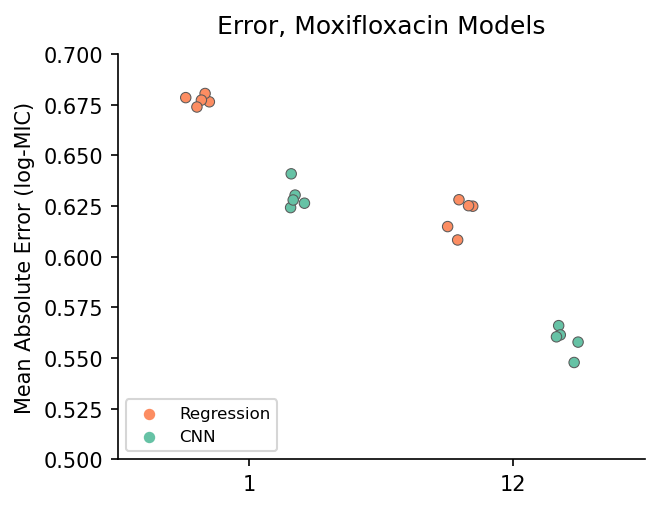

In [145]:
plot_quant_moxi("MAE", "Mean Absolute Error (log-MIC)", "Error, Moxifloxacin Models", "../Figures/moxi_mae.png")

In [29]:
def plot_binary_moxi(df, binary_var, ymin, legend_loc, save_title=None):
    
    moxi_binary_plot = df.query("CV > 0 & CC == 0.5").melt(id_vars=["Model", "Num_Loci"], value_vars=[binary_var])
    moxi_binary_plot["Model"] = moxi_binary_plot["Model"].replace("LinReg", "Regression")
    moxi_binary_plot["Model"] = moxi_binary_plot["Model"].replace("LogReg", "Regression")
    # moxi_binary_plot["Num_Loci"] = moxi_binary_plot["Num_Loci"].replace("1", "Quant.\n$\it{gyrBA}$-only")
    # moxi_binary_plot["Num_Loci"] = moxi_binary_plot["Num_Loci"].replace("12", "Quant.\n12 Loci")

    fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
    sns.stripplot(x="Num_Loci", y="value",
                    hue="Model", 
                    data = moxi_binary_plot,
                    palette=color_dict,
                  hue_order=["Regression", "CNN"],
                  #order=["Binary", "Quant.\n$\it{gyrBA}$-only", "Quant.\n12 Loci"],
                      dodge=True,
                  #alpha=0.75,
                  linewidth=0.5,
                  ax=ax
                     )



    plt.ylim(ymin, 1)
    ax.get_legend().remove()
    plt.title(f"{binary_var}, Moxifloxacin Models")
    #+ " of Rifampicin prediction from $\it{rpoBC}$")
    plt.xlabel("")
    
    legend = plt.legend(loc=legend_loc, fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.ylabel(binary_var)
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)
        
    print("Binary vs. Quant CNN t-test:")
    print(st.ttest_rel(moxi_combined.query("Model == 'CNN' & Num_Loci == 'Binary' & CV > 0 & CC == 0.5").sort_values("CV")[binary_var].values,
                 moxi_combined.query("Model == 'CNN' & Num_Loci == '1' & CV > 0  & CC == 0.5").sort_values("CV")[binary_var].values,
                 alternative="two-sided"
                ))

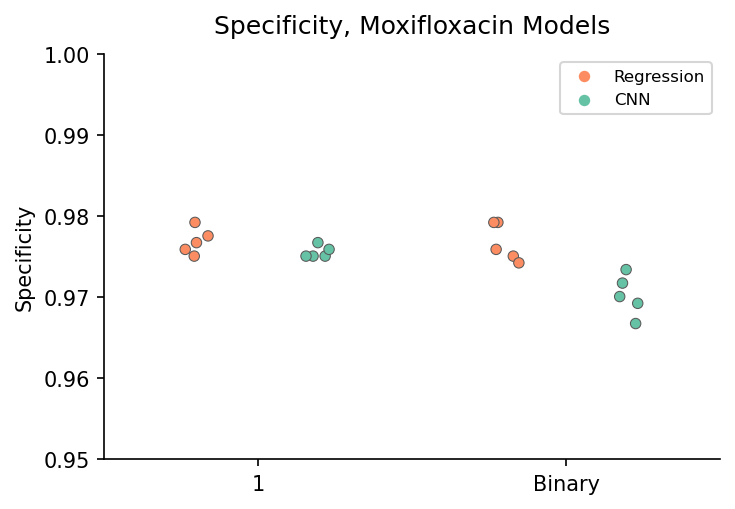

Binary vs. Quant CNN t-test:
Ttest_relResult(statistic=-5.70157316079874, pvalue=0.004677048676783796)


In [32]:
plot_binary_moxi(moxi_combined.query("Lineage==0 & Num_Loci != '12'"), "Specificity", 0.95, "upper right", save_title=None)

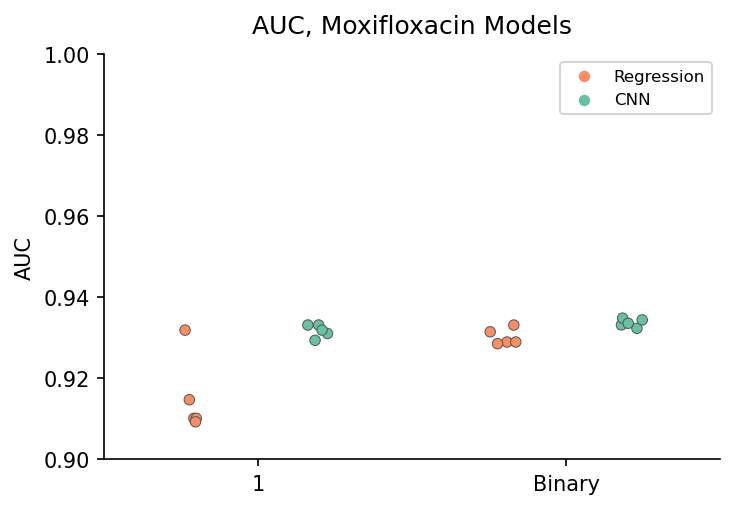

Binary vs. Quant CNN t-test:
Ttest_relResult(statistic=1.7637323840410135, pvalue=0.15255090668500976)


In [34]:
plot_binary_moxi(moxi_combined.query("Lineage==0 & Num_Loci != '12'"), "AUC", 0.9, "upper right", save_title=None)

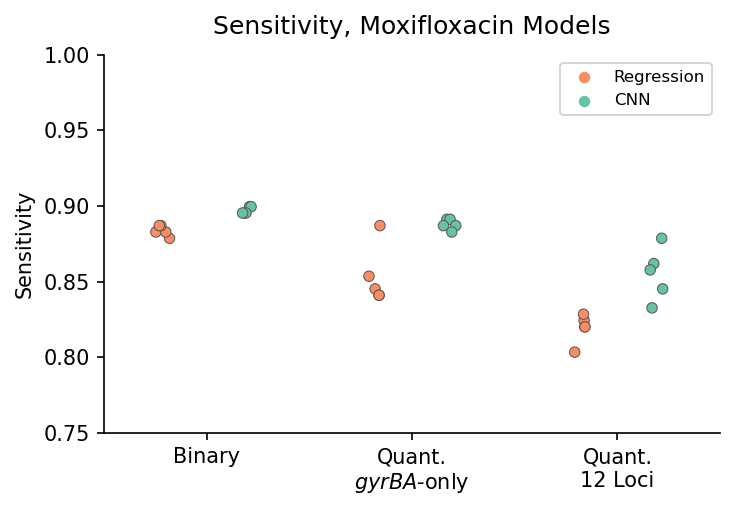

Binary vs. Quant CNN t-test:
Ttest_relResult(statistic=5.879747322073301, pvalue=0.004181072135640391)


In [187]:
plot_binary_moxi("Sensitivity", 0.75, "upper right", save_title=None)

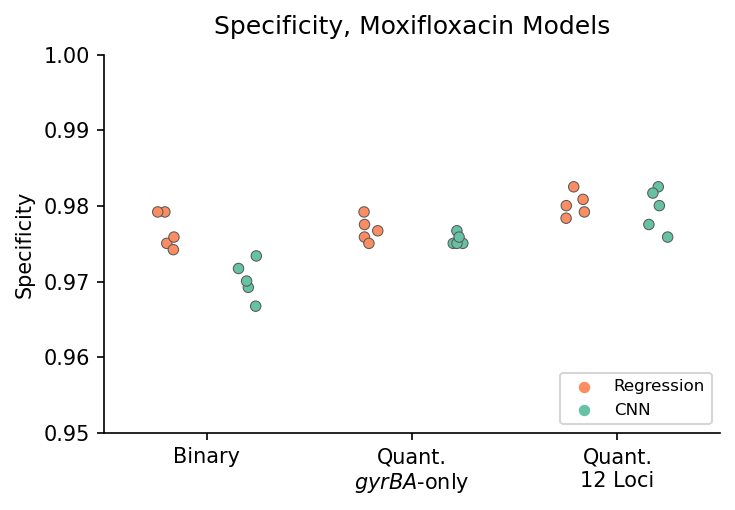

Binary vs. Quant CNN t-test:
Ttest_relResult(statistic=-5.70157316079874, pvalue=0.004677048676783796)


In [194]:
plot_binary_moxi("Specificity", 0.95, "lower right", save_title=None)

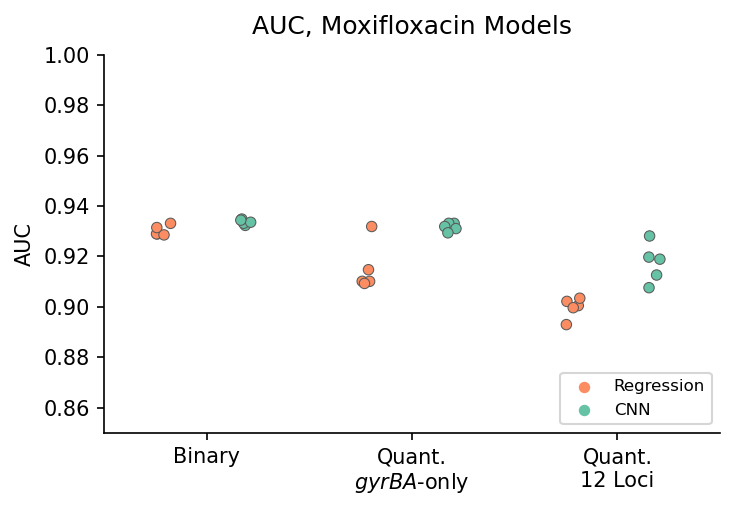

Binary vs. Quant CNN t-test:
Ttest_relResult(statistic=1.7637323840410135, pvalue=0.15255090668500976)


In [195]:
plot_binary_moxi("AUC", 0.85, "lower right", save_title=None)

In [88]:
def change_width(ax, new_value) :
    for patch in ax.patches :
        current_width = patch.get_width()
        diff = current_width - new_value

        # we change the bar width
        patch.set_width(new_value)

        # we recenter the bar
        patch.set_x(patch.get_x() + diff * .5)
        
        
        
def true_value_plot(df, value_to_plot, num_loci_order, labels_list, new_bar_width, title=None, fix_model_names=True):
    
    plot_df = df.query("Num_Loci in @num_loci_order & CV == 0").reset_index(drop=True)
    
    if fix_model_names:
        for i, row in plot_df.iterrows():
            if "reg" in row["Model"].lower():
                plot_df.loc[i, "Model"] = "Regression"
            elif "CNN" in row["Model"]:
                plot_df.loc[i, "Model"] = "CNN"
            else:
                plot_df.loc[i, "Model"] = row["Model"]
                        
    plot_df["Group_Num"] = plot_df["Num_Loci"].map(dict(zip(num_loci_order, 
                                                            np.arange(len(num_loci_order))
                                                            )
                                                        )
                                                )
    
    if len(labels_list) != len(plot_df["Group_Num"].unique()):
        raise ValueError("Numbers of labels and unique groups are not equal!")
        
    palette = sns.color_palette("Set2")        
    ax = sns.barplot(data=plot_df, x="Group_Num", y=value_to_plot, hue="Model", palette="Set2")
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="center")
    change_width(ax, new_bar_width)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), 
               frameon=True, 
               #loc='upper center', bbox_to_anchor=(0.3, -0.2),
               #ncol=2
               bbox_to_anchor=(1, 0.35),
               loc="best",
               labelspacing=0.75
              )

    #plt.xlim(min_val, 1)
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"{value_to_plot}s of Moxifloxacin MIC Models")
        
    plt.xticks(ticks=np.sort(plot_df["Group_Num"].unique()), 
               labels=labels_list)

    sns.despine()
    plt.show()

In [57]:
# true_value_plot(plot_df, "MAE", [23, 22.5, 22, 1, 4000][::-1],
#                            ["22 loci\n N=7,315", "22 loci\n N=7,423", "22 loci\n N=7,423", "$\it{gyrBA}$ only \n N=7,423", " GWAS \n N=7,423"][::-1],
#                             0.4,
#                            fix_model_names=True)

In [58]:
# true_value_plot(plot_df, "Pearson R", [23, 22, 1, 4000][::-1],
#                            ["22 loci\n N=7,315", "22 loci\n N=7,423", "$\it{gyrBA}$ only \n N=7,423", " GWAS \n N=7,423"][::-1],
#                             0.4,
#                            fix_model_names=True)

In [59]:
# compare_model_performances(plot_df, "MAE", [22.5, 22],
#                            ["22 loci  \n N=7,315", "22 loci  \n N=7,423"],
#                            scale=0.125, fix_model_names=True)

In [111]:
gyrBA_only.query("Num_Loci == 1 & Model == 'CNN' & CV == 1")

,Drug,Model,Num_Loci,MAE,RMSE,Pearson R,Sensitivity,Specificity,AUC,AUC_PR,CV
13,MOXI,CNN,1.0,0.636386,0.898188,0.790165,0.891213,0.974231,0.932722,0.796016,1
14,MOXI,CNN,1.0,0.623940,0.904407,0.789186,0.882845,0.975062,0.928954,0.792365,1
15,MOXI,CNN,1.0,0.627414,0.907371,0.788676,0.891213,0.974231,0.932722,0.796016,1
16,MOXI,CNN,1.0,0.626829,0.905483,0.789488,0.878661,0.975062,0.926862,0.788939,1
17,MOXI,CNN,1.0,0.632751,0.903640,0.788400,0.887029,0.977556,0.932293,0.805545,1


In [118]:
print(st.ttest_ind(gyrBA_only.query("Num_Loci == 1 & Model == 'CNN' & CV == 1").AUC, gyrBA_only.query("Num_Loci == 0.5 & Model == 'CNN' & CV == 1").AUC, alternative='two-sided')[1])
print(st.ttest_ind(gyrBA_only.query("Num_Loci == 1 & Model != 'CNN' & CV == 1").AUC, gyrBA_only.query("Num_Loci == 0.5 & Model != 'CNN' & CV == 1").AUC, alternative='two-sided')[1])



3.4050667067313943e-06
0.011755049247167885


In [123]:
# compare_model_performances(plot_df, "MAE", [23, 22, 1, 4000],
#                            ["22 loci  \n N=7,315", "22 loci  \n N=7,423", "$\it{gyrBA}$ only \n N=7,423  ", "GWAS  \n N=7,423"],
#                            scale=0.125, fix_model_names=True)

In [159]:
def compare_model_performances(df, value_to_plot, num_loci_order, labels_list, limits=(0,1), scale=0.25, title=None, fix_model_names=True):
    
    plot_df = df.query("Num_Loci in @num_loci_order").reset_index(drop=True)
    
    if fix_model_names:
        for i, row in plot_df.iterrows():
            if "reg" in row["Model"].lower():
                plot_df.loc[i, "Model"] = "Regression"
            elif "CNN" in row["Model"]:
                plot_df.loc[i, "Model"] = "CNN"
            else:
                plot_df.loc[i, "Model"] = row["Model"]
                        
    plot_df["Group_Num"] = plot_df["Num_Loci"].map(dict(zip(num_loci_order, 
                                                            np.arange(len(num_loci_order))
                                                            )
                                                        )
                                                )
    

    palette = sns.color_palette("Set2")
    palette = palette.as_hex()
    color_dict = dict(zip(plot_df["Model"].unique(), palette[:len(plot_df["Model"].unique())]))
    
    if len(labels_list) != len(plot_df["Group_Num"].unique()):
        raise ValueError("Numbers of labels and unique groups are not equal!")
    
    fig, ax = plt.subplots(figsize=(5, 3))

    for i, group in enumerate(np.sort(plot_df["Group_Num"].unique())):
        
        # to dodge points
        unique_models = plot_df.query("Group_Num == @group")["Model"].unique()
        
        if len(unique_models) == 1:
            pos_lst = [group]
        else:
            pos_lst = np.linspace(group-scale, group+scale, num=len(unique_models))
        
        # CNN comes before everything else
        for k, model in enumerate(np.sort(unique_models)):
                        
            single_group_df = plot_df.query("Group_Num == @group & Model == @model")
            
            if len(single_group_df) > 0:
                #true_val = single_group_df.query("CV==0")[value_to_plot].values[0]
                mean = single_group_df.query("CV==1")[value_to_plot].mean()
                #ci_lower, ci_upper = np.percentile(single_group_df.query("CV==1")[value_to_plot], q=[2.5, 97.5])

                ax.errorbar(x=single_group_df.query("CV==1")[value_to_plot],
                             #y=[group+k/scale]*5, 
                            y=[pos_lst[k]]*5,
                            #xerr=np.array([[mean-ci_lower], [ci_upper-mean]]),
                             elinewidth=1,
                               color=color_dict[model],
                               label=model,
                            )
                ax.scatter(x=mean, 
                           #y=group+k/scale,
                           y=pos_lst[k],
                           color=color_dict[model], 
                      )

    plt.yticks(ticks=(np.sort(plot_df["Group_Num"].unique())), 
               labels=labels_list)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), 
               frameon=True, 
               #loc='upper center', bbox_to_anchor=(0.3, -0.2),
               #ncol=2
               bbox_to_anchor=(1, 0.8),
               labelspacing=0.75
              )
    #ax.legend(bbox_to_anchor=(1.1, 1.05))

    plt.xlim(limits[0], limits[1])
    plt.title(f"{value_to_plot} of {title}")
    sns.despine()
    plt.show()

# Plots of Confidence Intervals

Difference in sensitivities between gyrBA-only and 7-loci moxi models is nominally significant (0.05-0.1). 

In [ ]:
def change_width(ax, new_value) :
    for patch in ax.patches :
        current_width = patch.get_width()
        diff = current_width - new_value

        # we change the bar width
        patch.set_width(new_value)

        # we recenter the bar
        patch.set_x(patch.get_x() + diff * .5)
        
# g = sns.catplot(
#     #data=plot_summary_df.query("variable == 'AUC' | variable == 'AUC_PR'"), 
#     data=plot_summary_df,
#     sharey=False,
#     kind="bar",
#     col="variable",
#     col_wrap=2,
#     x="Num_Loci", y="value", 
#     hue="Algorithm",
#     palette="Set2", 
#     alpha=1, 
#     height=6,
#     aspect=1.25,
#     ci="sd",
#     errwidth=1.5,
#     capsize=0.05,
#     order=["RIF", 1, 7]
# )
# g.despine()
# g.set_axis_labels("", "")
# g.legend.set_title("")

# axs = g.axes
# for ax in axs:
#     ax.bar_label(ax.containers[0], fmt='%.2f', label_type="center")
#     ax.bar_label(ax.containers[1], fmt='%.2f', label_type="center")
#     change_width(ax, 0.3)
# #plt.title("Mean Absolute Errors of Quantitative Models", loc='center')
# plt.xticks(ticks=ax.get_xticks(), labels=["Rifampicin, $\it{rpoBC}$", "Moxifloxacin, $\it{gyrBA}$", "Moxifloxacin, 7 Loci"])

# #plt.savefig("quant_mae_barChart.png", dpi=300, bbox_inches='tight')
# plt.show()